<div style="text-align:left;font-size:2em"><span style="font-weight:bolder;font-size:1.25em">SP2273 | Learning Portfolio</span><br><br><span style="font-weight:bold;color:darkred">Plotting (Good)</span></div>

In [112]:
import numpy as np
from matplotlib import pyplot as plt

plt.style.use('default')

# Plotting a Maxwell-Boltzmann Distribution curve for fun 

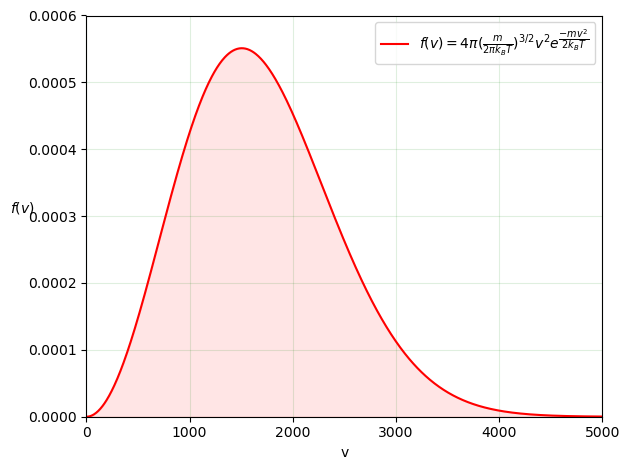

In [52]:
m = 2 * 1.66* 10**-27
k = 1.38 * 10**-23
T = 273
x = np.linspace(0, 5000, 1000)
y = 4 * np.pi * (m/(2 * np.pi * k * T))**(3/2) * (x**2) * np.exp((-1 * m * x**2)/(2 * k * T))
plt.plot(x,y, color = 'red', label = r"$f(v)=4 \pi (\frac{m}{2 \pi k_{B} T})^{3/2} v^2 e^{\dfrac{-mv^2}{2k_{B}T}}$")
plt.fill_between(x,y, alpha = .1, color = 'red')
plt.legend()
plt.xlabel('v')
plt.ylabel(r"$f(v)$", rotation = 0)
plt.xlim([0,5000])
plt.ylim([0,0.0006])
plt.grid(alpha = .125, color = 'green')
plt.tight_layout()

# Figure and Axes

- A figure is the full canvas that all the graphs will be plotted

- Axes are the individual x & y axes for each graph

- We can specify how many axes we want in each row and column for a figure 

- Syntax: `fig, ax = plt.subplots(nrows = {int}, ncols = {int}, figsize = (),sharex = {}, sharey = {})`

- ax is an array containing all the axes in the figure. To plot graphs on each axis, you need to call the plot() method on the specific axis using indexing 

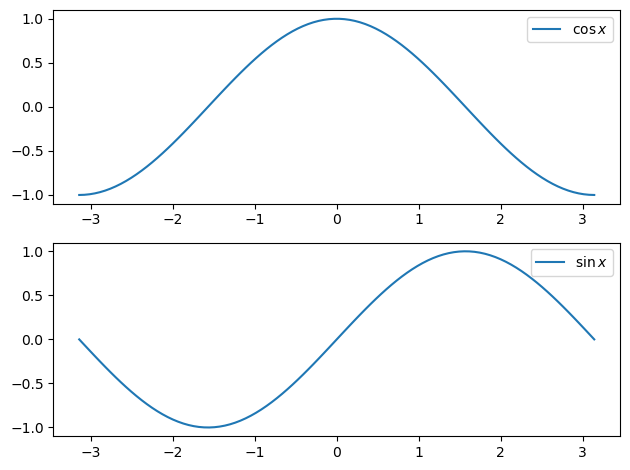

In [118]:
x = np.linspace(-np.pi, np.pi, 100)
cos_x = np.cos(x)
sin_x = np.sin(x)

fig, ax = plt.subplots(nrows = 2, ncols = 1)
ax[0].plot(x, cos_x, label = r'$\cos x$')
ax[1].plot(x, sin_x, label = r'$\sin x$')

ax[0].legend()
ax[1].legend()

plt.tight_layout()


- Note: pyplot and OO Interface use slightly different functions names
    - pyplot uses xlim while OO Interface uses set_xlim
    - pyplot uses xlabel while OO Interface uses set_xlabel

---

# Multiple Rows and Columns

- For axes with multiple rows and columns, if you want to loop through the axes, you must first use `ax.flatten()` to convert the multi dimensional array into a 1D array

- axes indexing: `ax[row:column]`

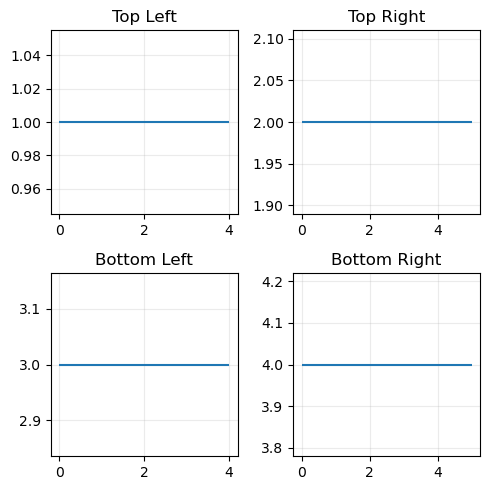

In [120]:
fig, ax = plt.subplots(nrows=2, ncols=2,
                       figsize=(5, 5))

#Flattening the 2D array into a 1D array and unpacking the axes
top_left, top_right, bottom_left, bottom_right = ax.flatten()

top_left.set_title('Top Left')
top_right.set_title('Top Right')
bottom_left.set_title('Bottom Left')
bottom_right.set_title('Bottom Right')

top_left.hlines(y=1, xmin=0, xmax=4)
top_right.hlines(y=2, xmin=0, xmax=5)
bottom_left.hlines(y=3, xmin=0, xmax=4)
bottom_right.hlines(y=4, xmin=0, xmax=5)

for a in ax.flatten():
    a.grid(alpha=.25)

plt.tight_layout()

---

# Sharing Axes

- True: Makes all the axes use the same range

- col: Use the same range for each col

- row: Use the same range for each row 

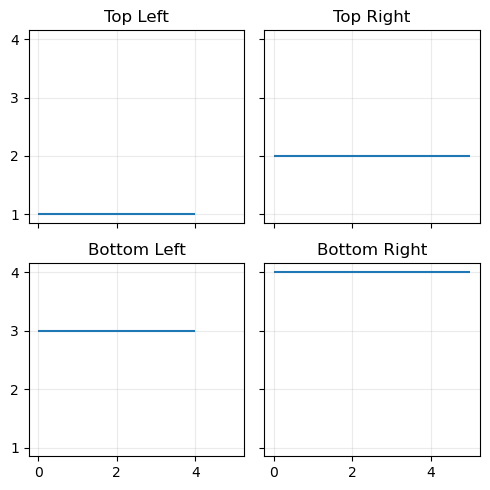

In [ ]:
#All the rows and columns share the same x and y axes

fig, ax = plt.subplots(nrows=2, ncols=2,
                       figsize=(5, 5), sharex = True, sharey = True)

top_left, top_right, bottom_left, bottom_right = ax.flatten()

top_left.set_title('Top Left')
top_right.set_title('Top Right')
bottom_left.set_title('Bottom Left')
bottom_right.set_title('Bottom Right')

top_left.hlines(y=1, xmin=0, xmax=4)
top_right.hlines(y=2, xmin=0, xmax=5)
bottom_left.hlines(y=3, xmin=0, xmax=4)
bottom_right.hlines(y=4, xmin=0, xmax=5)

for a in ax.flatten():
    a.grid(alpha=.25)

plt.tight_layout()

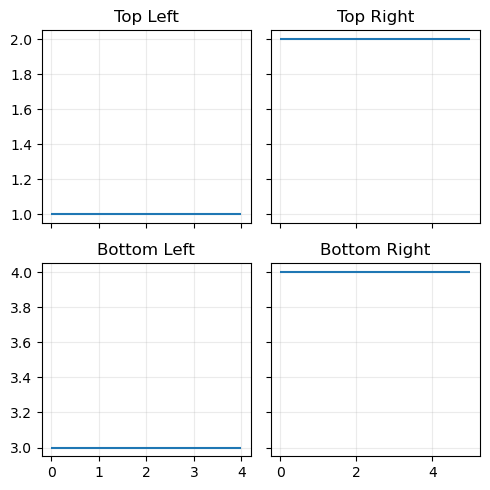

In [ ]:
#Plots in same column will share x axis, while plots in the same row will share y axis

fig, ax = plt.subplots(nrows=2, ncols=2,
                       figsize=(5, 5), sharex = 'col', sharey = 'row')

top_left, top_right, bottom_left, bottom_right = ax.flatten()

top_left.set_title('Top Left')
top_right.set_title('Top Right')
bottom_left.set_title('Bottom Left')
bottom_right.set_title('Bottom Right')

top_left.hlines(y=1, xmin=0, xmax=4)
top_right.hlines(y=2, xmin=0, xmax=5)
bottom_left.hlines(y=3, xmin=0, xmax=4)
bottom_right.hlines(y=4, xmin=0, xmax=5)

for a in ax.flatten():
    a.grid(alpha=.25)

plt.tight_layout()

---

# Histograms

- Histograms can be plotted using: `plt.hist(x, bins = {int}, range = ({lower_lim}, {upper_lim}), label = {string})`. 
    - x is a single array/ sequence of arrays that do not need to be of the same length
    - bins is the number of equal width bins 
    - range is a tuple specifying the lower and upper limit of the bins

- If multiple variables are to be plotted, pass the variables as a list

In [25]:
def get_plot_data():
    data = {}
    filename = 'sg-gov-graduate-employment-survey_basic_monthly_mean_all.csv'  #storing the name of the file in a variable
    data['All'] = np.loadtxt(filename, skiprows=1) 

    filename = 'sg-gov-graduate-employment-survey_basic_monthly_mean_nus.csv'
    data["NUS"] = np.loadtxt(filename, skiprows=1)
    return data

#returns a dictionary of arrays 

data = get_plot_data()  #Call the function to retrieve the two data files 
print(data)

{'All': array([3701., 2850., 3053., ..., 3856., 3303., 3245.], shape=(1007,)), 'NUS': array([2741., 3057., 3098., 2960., 3404., 2740., 3065., 3350., 3933.,
       3277., 3266., 4106., 3007., 2961., 2839., 2823., 3245., 3140.,
       3592., 3286., 2940., 3153., 3330., 3036., 3155., 4922., 4406.,
       2687., 2896., 2850., 2726., 3101., 3473., 2719., 3141., 3192.,
       3234., 3979., 2836., 3350., 3107., 3729., 3183., 3684., 4054.,
       4290., 2600., 3089., 2931., 2966., 3277., 3212., 3674., 3306.,
       3375., 3250., 3591., 3054., 3160., 5027., 4404., 2976., 3123.,
       2760., 2804., 3224., 3467., 2839., 3266., 3317., 3164., 4173.,
       2817., 3547., 3230., 3847., 3255., 3597., 4053., 4054., 2907.,
       2989., 3146., 3256., 3400., 3300., 4119., 3452., 3768., 3318.,
       3624., 3121., 3279., 4866., 4352., 3175., 3219., 3244., 3203.,
       2859., 3245., 3431., 3400., 2971., 3258., 3341., 4173., 3314.,
       3414., 3402., 3884., 3669., 3549., 3432., 3788., 3381., 3470.,
    

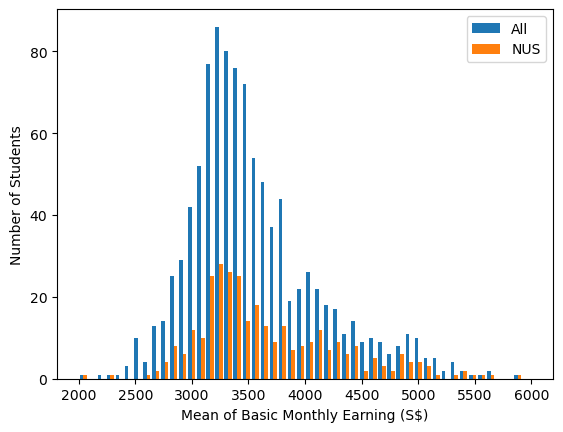

In [78]:
plt.hist([data["All"], data["NUS"]], bins = 50, range = (2000, 6000,), label = ["All", "NUS"])
plt.xlabel('Mean of Basic Monthly Earning (S$)')
plt.ylabel('Number of Students')
plt.legend()
plt.show()

---

# Scatter Plot

- Scatter plots are created by plotting a **point** for each (x,y) specified 

- This can be done using `plt.scatter(x,y)`

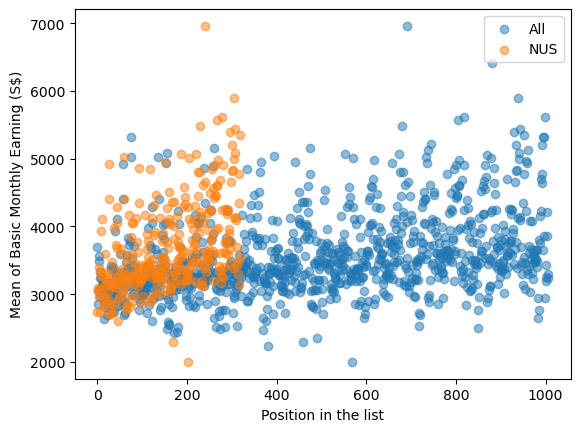

In [76]:
data = get_plot_data()

#data gives a dictionary of arrays. Calling the items() function outputs it as a list
for label, numbers in data.items():
    x = range(len(numbers)) 
    y = numbers 
    plt.scatter(x,y, label = label, alpha = .5)

plt.xlabel('Position in the list')
plt.ylabel('Mean of Basic Monthly Earning (S$)')
plt.legend()

---

# Bar Graphs

- Bar graphs can be created using plt.bar(x, height)

- For horizontal bar graphs, use barh()

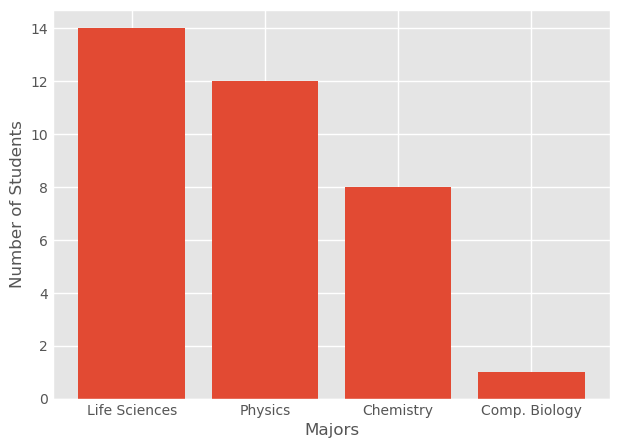

In [105]:
student_numbers = {'Life Sciences': 14,
                   'Physics': 12,
                   'Chemistry': 8,
                   'Comp. Biology': 1}
majors = list(student_numbers.keys())
numbers = list(student_numbers.values())

plt.bar(majors, numbers)
plt.xlabel('Majors')
plt.ylabel('Number of Students')
plt.show()

---

# Pie Charts

- Pie Charts can be created using `plt.pie(x, labels = {string})`

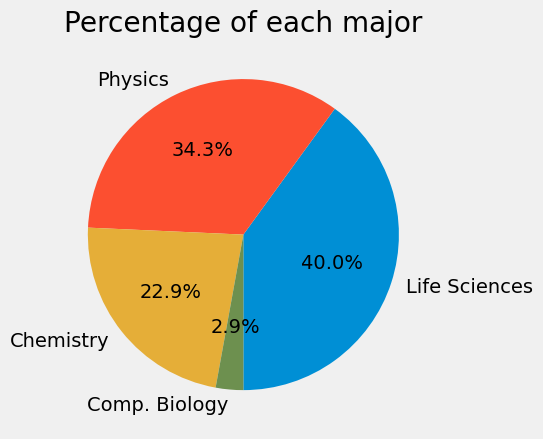

In [91]:
student_numbers = {'Life Sciences': 14,
                   'Physics': 12,
                   'Chemistry': 8,
                   'Comp. Biology': 1}
majors = list(student_numbers.keys())
numbers = list(student_numbers.values())

plt.style.use('fivethirtyeight')
plt.pie(numbers, 
        labels=majors,
        autopct='%1.1f%%',   # How to format the percentages
        startangle=-90                
        )
plt.title('Percentage of each major')
plt.show()